In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# Parameter windowing
input_width = int(48)*1
label_width = 48
shift = label_width
total_window_size = input_width + shift
OUT_STEPS = label_width
# Definisikan irisan untuk input dan label
input_slice = slice(0, input_width)
label_start = total_window_size - label_width
labels_slice = slice(label_start, None)

from C_template import  scale_array, inverse_scale_array,  process_predictions, compute_metrics, compute_error, make_multi_input_windows, make_windows_autoregressive

# data training

In [2]:
data_training_awal= pd.read_excel('D:\\JAMALI FORECASTING\\B_train_data.xlsx', index_col=0)
data_training= data_training_awal.astype('float32').copy()
data_training

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2022-01-01 00:30:00,18402.000000,0.130526,0.991445,-0.974928,-0.222521,0.0,1.000000e+00,0.762049,-4.403535
2022-01-01 01:00:00,18214.000000,0.258819,0.965926,-0.974928,-0.222521,0.0,1.000000e+00,0.762049,-4.566491
2022-01-01 01:30:00,17974.000000,0.382683,0.923880,-0.974928,-0.222521,0.0,1.000000e+00,0.762049,-4.811594
2022-01-01 02:00:00,17729.000000,0.500000,0.866025,-0.974928,-0.222521,0.0,1.000000e+00,0.762049,-5.056697
2022-01-01 02:30:00,17532.000000,0.608761,0.793353,-0.974928,-0.222521,0.0,1.000000e+00,0.762049,-5.223890
...,...,...,...,...,...,...,...,...,...
2024-10-30 22:00:00,29019.070312,-0.500000,0.866025,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,0.447690
2024-10-30 22:30:00,28465.740234,-0.382683,0.923880,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,0.134316
2024-10-30 23:00:00,27755.750000,-0.258819,0.965926,0.974928,-0.222521,-1.0,-1.836970e-16,1.012018,-0.179059


In [3]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49632.000000,4.963200e+04,4.963200e+04,49632.000000,49632.000000,4.963200e+04,4.963200e+04,49632.000000,49632.000000
mean,24933.849609,1.229754e-09,0.000000e+00,0.000028,0.001729,3.786855e-02,-4.467865e-02,1.000537,-0.297909
std,3040.183838,7.071139e-01,7.071139e-01,0.707530,0.706637,7.057171e-01,7.060366e-01,0.047190,4.279032
min,13475.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,0.697430,-10.782065
25%,22701.939941,-7.071068e-01,-7.071068e-01,-0.781832,-0.900969,-5.000000e-01,-8.660254e-01,1.012018,-3.767943
50%,24934.724609,6.123234e-17,-6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,1.012018,-1.268959
75%,27240.225586,7.071068e-01,7.071068e-01,0.781832,0.623490,8.660254e-01,5.000000e-01,1.012018,2.886689
max,32758.619141,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.012018,13.803565


In [4]:
data_training['Suhu_PCA'], min_suhu, max_suhu = scale_array(
    data_training['Suhu_PCA'].values, 
    new_min=-1,
    new_max=1)

data_training['Holiday_Impact'], min_holiday, max_holiday = scale_array(
    data_training['Holiday_Impact'].values, 
    new_min=-1, 
    new_max=1
)

data_training['Beban'], min_beban, max_beban = scale_array(
    data_training['Beban'].values, 
    new_min=-1, 
    new_max=1)

Computed orig_min: -10.782065391540527
Computed orig_max: 13.80356502532959
Computed orig_min: 0.6974297761917114
Computed orig_max: 1.0120183229446411
Computed orig_min: 13475.0
Computed orig_max: 32758.619140625


In [5]:
data_training.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,49632.000000,4.963200e+04,4.963200e+04,49632.000000,49632.000000,4.963200e+04,4.963200e+04,49632.000000,49632.000000
mean,0.188454,1.229754e-09,0.000000e+00,0.000028,0.001729,3.786855e-02,-4.467865e-02,0.927008,-0.147131
std,0.315313,7.071139e-01,7.071139e-01,0.707530,0.706637,7.057171e-01,7.060366e-01,0.300029,0.348093
min,-1.000000,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,-1.000000,-1.000000
25%,-0.043028,-7.071068e-01,-7.071068e-01,-0.781832,-0.900969,-5.000000e-01,-8.660254e-01,1.000000,-0.429413
50%,0.188545,6.123234e-17,-6.123234e-17,0.000000,-0.222521,1.224647e-16,-1.836970e-16,1.000000,-0.226125
75%,0.427660,7.071068e-01,7.071068e-01,0.781832,0.623490,8.660254e-01,5.000000e-01,1.000000,0.111930
max,1.000000,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000e+00,1.000000e+00,1.000000,1.000000


# data validation (testing)

In [6]:
data_validation_awal= pd.read_excel('D:\\JAMALI FORECASTING\\B_test_data.xlsx', index_col=0)
data_validation= data_validation_awal.astype('float32').copy()
data_validation

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
Date,,,,,,,,,
2024-10-31 00:30:00,26460.919922,1.305262e-01,0.991445,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-0.829108
2024-10-31 01:00:00,26184.929688,2.588190e-01,0.965926,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.032705
2024-10-31 01:30:00,25976.689453,3.826834e-01,0.923880,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.284443
2024-10-31 02:00:00,25745.220703,5.000000e-01,0.866025,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.536183
2024-10-31 02:30:00,25441.970703,6.087614e-01,0.793353,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,-1.717856
...,...,...,...,...,...,...,...,...,...
2025-10-30 10:00:00,30957.800781,5.000000e-01,-0.866025,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,3.765654
2025-10-30 10:30:00,30580.789062,3.826834e-01,-0.923880,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,4.427866
2025-10-30 11:00:00,31497.359375,2.588190e-01,-0.965926,0.433884,-0.900969,-1.0,-1.836970e-16,1.012018,5.090077


In [7]:
data_validation['Suhu_PCA'], _, _ = scale_array(
    data_validation['Suhu_PCA'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_suhu,
    orig_max=max_suhu
)
data_validation['Holiday_Impact'], _, _ = scale_array(
    data_validation['Holiday_Impact'].values,
    new_min=-1,
    new_max=1,
    orig_min=min_holiday,
    orig_max=max_holiday
)
data_validation['Beban'], _, _ = scale_array(
    data_validation['Beban'].values, 
    new_min=-1, 
    new_max=1,
    orig_min=min_beban,
    orig_max=max_beban
)

In [8]:
data_validation.describe()

,Beban,Jam_sin,Jam_cos,Hari_sin,Hari_cos,Bulan_sin,Bulan_cos,Holiday_Impact,Suhu_PCA
count,17496.000000,1.749600e+04,1.749600e+04,17496.000000,17496.000000,17496.000000,1.749600e+04,17496.000000,17496.000000
mean,0.389520,8.720320e-04,-5.715587e-05,0.000595,-0.001236,-0.002107,-4.751840e-03,0.927556,-0.054150
std,0.317044,7.071220e-01,7.071295e-01,0.706819,0.707422,0.706636,7.075914e-01,0.295125,0.311896
min,-0.775485,-1.000000e+00,-1.000000e+00,-0.974928,-0.900969,-1.000000,-1.000000e+00,-1.000000,-0.847113
25%,0.158968,-7.071068e-01,-7.071068e-01,-0.781832,-0.900969,-0.500000,-8.660254e-01,1.000000,-0.310872
50%,0.385124,1.224647e-16,-6.123234e-17,0.000000,-0.222521,0.000000,-1.836970e-16,1.000000,-0.119035
75%,0.668971,7.071068e-01,7.071068e-01,0.781832,0.623490,0.866025,5.000000e-01,1.000000,0.207501
max,1.139628,1.000000e+00,1.000000e+00,0.974928,1.000000,1.000000,1.000000e+00,1.000000,0.836694


# training model

In [9]:
input_make_windows      =   data_training.to_numpy()
output_make_windows     =   data_training['Beban'].to_numpy()
periodic_indices = data_training.columns.get_indexer(['Jam_sin','Jam_cos', 'Hari_sin', 'Hari_cos', 'Bulan_sin', 'Bulan_cos'])
    
x_train, x_train_periodic, y_train = make_multi_input_windows(input_make_windows,
                                                         output_make_windows,
                                                         total_window_size=total_window_size, 
                                                         input_slice=input_slice,
                                                         labels_slice=labels_slice, 
                                                         periodic_indices=periodic_indices)

In [10]:
input_make_windows_validation   = data_validation.to_numpy()
output_make_windows_validation  = data_validation['Beban'].to_numpy()
x_val, x_val_periodic, y_val                   = make_multi_input_windows(input_make_windows_validation, 
                                                           output_make_windows_validation,
                                                           total_window_size=total_window_size,
                                                             input_slice=input_slice, 
                                                             labels_slice=labels_slice,
                                                             periodic_indices=periodic_indices)

In [11]:
x_train.shape, y_train.shape,  x_train_periodic.shape, x_val.shape, y_val.shape,  x_val_periodic.shape,

((49537, 48, 9),
 (49537, 48),
 (49537, 48, 6),
 (17401, 48, 9),
 (17401, 48),
 (17401, 48, 6))

In [12]:
x_train.dtype, y_train.dtype, x_train_periodic.dtype, x_val.dtype, y_val.dtype, x_val_periodic.dtype, 

(dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'),
 dtype('float32'))

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Concatenate
import time
import json
from tensorflow.keras.callbacks import History, ModelCheckpoint, EarlyStopping

def build_model_tensor(input_lag, num_features, forecast_horizon, periodic_features):
    
    # Branch 1: CNN for History
    input_history = Input(shape=(input_lag, num_features), name='historical_input')
    x1 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal', dilation_rate=1)(input_history)
    cnn_out = Flatten()(x1)

    # Branch 2: Fully Connected for Future Periodic Coding
    input_periodic = Input(shape=(forecast_horizon, periodic_features), name='periodic_input')
    x2 = Flatten()(input_periodic)
    periodic_out = Dense(32, activation='relu')(x2)

    # [cite_start]Fusion Layer: Concatenate historical patterns with future timing [cite: 273, 276]
    merged = Concatenate()([cnn_out, periodic_out])
    merged = Dense(32, activation='relu')(merged)
    
    # Output: 48 step load forecast 
    final_output = Dense(forecast_horizon, name='forecast_output')(merged)

    model = Model(inputs=[input_history, input_periodic], outputs=final_output)
    return model

In [14]:
def tensorflow_model(X_train_scaled, Y_train_scaled,
                     X_val_scaled,   Y_val_scaled,
                     learning_rate=1e-3,
                     target_MAE=0.001,
                     jumlah_epochs=50,
                     jumlah_sampel_batch=32, 
                     jumlah_epoch_terbelakang=10,
                     save_best_model_path="model.h5",
                     validation_data=False,
                     load_model=None, seed_value=-1):

    # Removing global variables for safer execution
    loss_history = {}

    # ---------- callbacks ----------
    class MAEStop(tf.keras.callbacks.Callback):
        def __init__(self, thr): super().__init__(); self.thr = thr
        def on_epoch_end(self, epoch, logs=None):
            if logs and logs.get('mae', 1e9) < self.thr:
                print(f"\nMAE < {self.thr}. Stop."); self.model.stop_training = True

    class SaveEveryNEpoch(tf.keras.callbacks.Callback):
        def __init__(self, n, root): super().__init__(); self.n, self.root = n, root
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % self.n == 0:
                fname = f"{self.root}_epoch{epoch+1:02d}.h5"
                self.model.save(fname)
                print(f"\n📦  Saved checkpoint: {fname}")

    class LiveLossLogger(tf.keras.callbacks.Callback):
        def __init__(self, filename, use_validation):
            super().__init__()
            self.filename = filename
            self.use_validation = use_validation
            self.live_history = {'loss': []}
            if self.use_validation:
                self.live_history['val_loss'] = []

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            
            current_loss = logs.get('loss')
            if current_loss is not None:
                self.live_history['loss'].append(float(current_loss))
            
            if self.use_validation:
                current_val_loss = logs.get('val_loss') 
                if current_val_loss is not None:
                    self.live_history['val_loss'].append(float(current_val_loss))
            
            with open(self.filename, 'w') as f:
                json.dump(self.live_history, f)

    history_cb = History()

    # ---------- model ----------
    # X_train_scaled is now a list [X_history, X_periodic]
    # We must extract the shapes from the specific array indices
    input_width  = X_train_scaled[0].shape[1]   
    num_features = X_train_scaled[0].shape[2]   
    periodic_feats = X_train_scaled[1].shape[2]
    forecast_horizon = Y_train_scaled.shape[1]
    
    if load_model is None:
        model = build_model_tensor(input_width, num_features, forecast_horizon, periodic_feats)
    else:
        model = tf.keras.models.load_model(load_model)

    model.summary()
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                  loss='mse',
                  metrics=['mse', 'mae',
                           tf.keras.metrics.MeanAbsolutePercentageError(name='mape')])

    # ---------- build callback list ----------
    json_filename = f"loss_history_{save_best_model_path}.json"
    
    cb = [
        history_cb,
        MAEStop(target_MAE),
        SaveEveryNEpoch(10, root=save_best_model_path.rstrip('.h5')),
        LiveLossLogger(json_filename, validation_data)
    ]

    if validation_data:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_mse',    
            factor=0.5,           
            patience=4,           
            min_lr=1e-6,          
            verbose=1             
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='val_mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='val_mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]
    else:
        lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='mse',        
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
        
        cb += [
            lr_scheduler,
            ModelCheckpoint(save_best_model_path,
                            monitor='mse', mode='min',
                            save_best_only=True, verbose=1),
            EarlyStopping(monitor='mse', mode='min',
                          patience=jumlah_epoch_terbelakang,
                          restore_best_weights=True, verbose=1)
        ]

    # ---------- training with exception handling ----------
    start = time.time()
    
    # Prepare validation tuple safely
    val_tuple = (X_val_scaled, Y_val_scaled) if validation_data else None

    try:
        model.fit(X_train_scaled, Y_train_scaled,
                  epochs=jumlah_epochs,
                  batch_size=jumlah_sampel_batch,
                  shuffle=False,
                  validation_data=val_tuple,
                  callbacks=cb,
                  verbose=True)
    except Exception as e:
        print("Training stopped with error:", e)
    finally:
        try:
            with open(json_filename, 'r') as f:
                loss_history = json.load(f)
        except FileNotFoundError:
            loss_history = {}
        print(f"Final training and validation loss securely saved to {json_filename}")

    print("Train time (s):", time.time() - start)

    # ---------- evaluate ----------
    loss, mse, mae, mape = model.evaluate(X_train_scaled, Y_train_scaled, verbose=0)
    print(f"Train  Loss={loss:.5f}  MSE={mse:.5f}  MAE={mae:.5f}  MAPE={mape:.3f}%")
    return model, loss, mse, mae, mape, loss_history

In [15]:

seed_vektor= [20]
for seed_value in seed_vektor:
    print(f"Running with seed: {seed_value}")
    tf.random.set_seed(seed_value)
    save_best_model_path = "TCN9_%s.h5"%seed_value
    model,     loss, MSE, MAE, MAPE, loss_history  = tensorflow_model(
        X_train_scaled=[x_train, x_train_periodic], Y_train_scaled=y_train, X_val_scaled=[x_val, x_val_periodic], Y_val_scaled=y_val, learning_rate=0.0001, target_MAE=0.001,  jumlah_epochs=2, jumlah_sampel_batch=1, 
                                                    jumlah_epoch_terbelakang=10,  save_best_model_path = save_best_model_path, 
                                                    validation_data=True, load_model=None, seed_value=seed_value)
    print(loss, MSE, MAE, MAPE)


Running with seed: 20
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 historical_input (InputLayer)  [(None, 48, 9)]      0           []                               
                                                                                                  
 periodic_input (InputLayer)    [(None, 48, 6)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 48, 64)       1792        ['historical_input[0][0]']       
                                                                                                  
 flatten_1 (Flatten)            (None, 288)          0           ['periodic_input[0][0]']         
                                                                        

Loading best model from:  TCN9_20.h5
544/544 [==============================] - 3s 6ms/step - loss: 0.0608 - mse: 0.0608 - mae: 0.1660 - mape: 280.0309
model.evaluate(x_val, y_val):  [0.06079749017953873, 0.06079749017953873, 0.16602137684822083, 280.0309143066406]
33/33 [==============================] - 0s 2ms/step
before dropna
                         Prediksi        Aktual
Date                                           
2022-01-02 00:30:00  26005.099609  17506.000000
2022-01-02 01:00:00  24867.128906  17293.000000
2022-01-02 01:30:00  23656.642578  17108.000000
2022-01-02 02:00:00  22354.580078  16876.000000
2022-01-02 02:30:00  20993.757812  16729.000000
...                           ...           ...
2024-10-30 22:00:00  26698.941406  29019.070312
2024-10-30 22:30:00  25840.519531  28465.740234
2024-10-30 23:00:00  25019.601562  27755.750000
2024-10-30 23:30:00  24184.250000  27277.500000
2024-10-31 00:00:00  23430.304688  26757.400391

[49584 rows x 2 columns]
after dropna
    

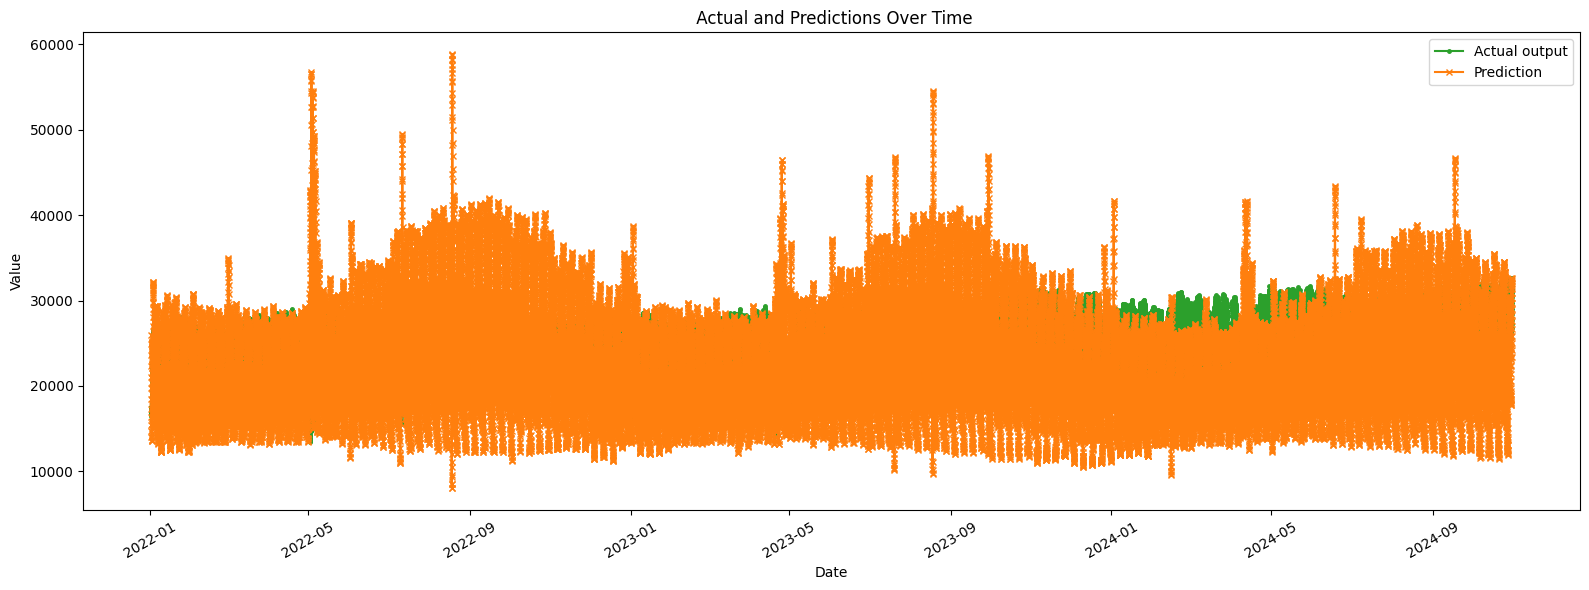

12/12 [==============================] - 0s 3ms/step
before dropna
                         Prediksi        Aktual
Date                                           
2024-11-01 00:30:00  17963.406250  26442.910156
2024-11-01 01:00:00  17221.337891  26127.140625
2024-11-01 01:30:00  16592.031250  26032.009766
2024-11-01 02:00:00  16070.514648  25634.070312
2024-11-01 02:30:00  15717.118164  25401.029297
...                           ...           ...
2025-10-30 10:00:00           NaN  30957.800781
2025-10-30 10:30:00           NaN  30580.789062
2025-10-30 11:00:00           NaN  31497.359375
2025-10-30 11:30:00           NaN  31337.589844
2025-10-30 12:00:00           NaN  20014.880859

[17448 rows x 2 columns]
after dropna
                         Prediksi        Aktual
Date                                           
2024-11-01 00:30:00  17963.406250  26442.910156
2024-11-01 01:00:00  17221.337891  26127.140625
2024-11-01 01:30:00  16592.031250  26032.009766
2024-11-01 02:00:00  16070.514

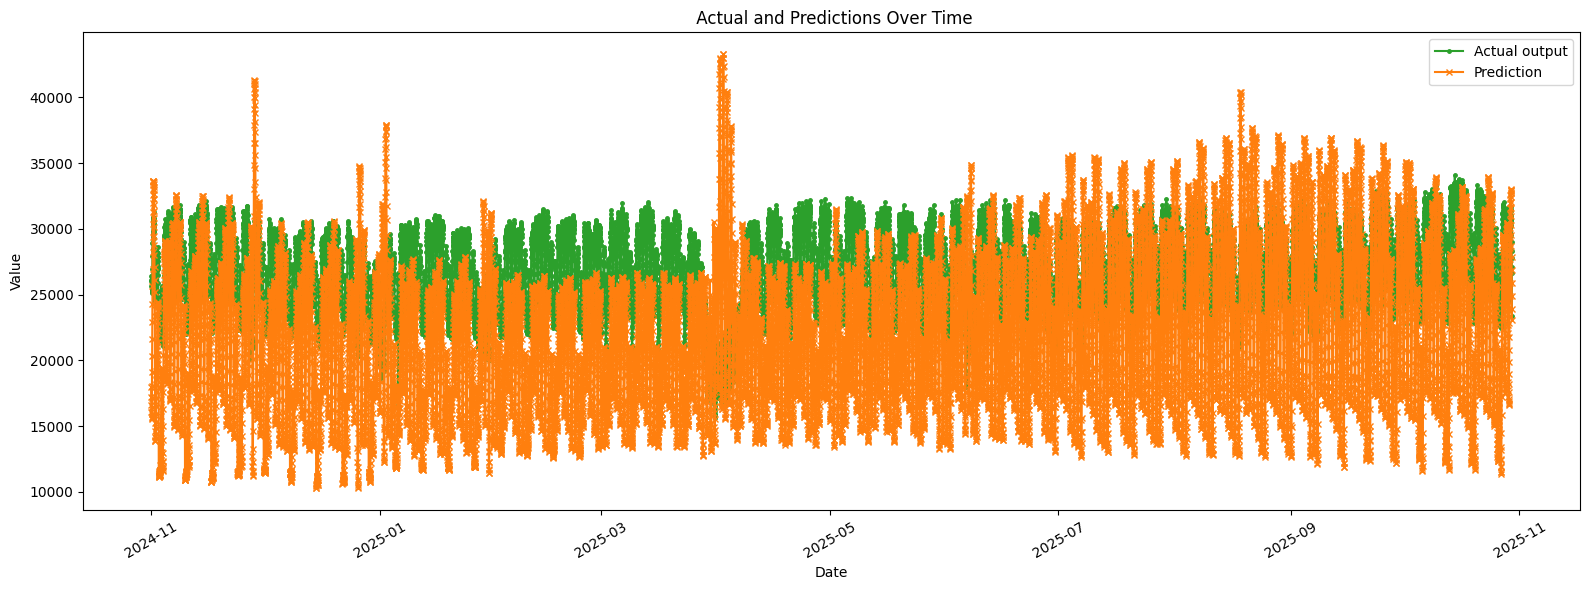

In [16]:
save_best_model_path
model.load_weights(save_best_model_path)
print("Loading best model from: ", save_best_model_path)
print("model.evaluate(x_val, y_val): ", model.evaluate([x_val, x_val_periodic], y_val))
predictions = model.predict([x_train[slice(None, None, label_width), :, :], x_train_periodic[slice(None, None, label_width), :, :]] )
predictions_reshaped = predictions.reshape(-1,)
predictions_unscaled = inverse_scale_array(predictions_reshaped, orig_min=min_beban, orig_max=max_beban)
df_pred_act = compute_error([x_train, x_train_periodic], 
                            data_training_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
print(df_pred_act)
df= df_pred_act.copy()
plt.figure(figsize=(16, 6))

# Plot the "Actual" as a green line with dot markers
plt.plot(
    df.index, 
    df['Aktual'], 
    label='Actual output', 
    marker='.', 
    markersize=5, 
    color='#2ca02c', 
    zorder=-100
)

# Scatter plot for "Prediction" in orange X markers
plt.plot(
    df.index, 
    df['Prediksi'], 
    marker='x', 
    markersize=5, 
    #edgecolors='k', 
    label='Prediction', 
    c='#ff7f0e', 
    #s=15
)

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=30)
plt.title(' Actual and Predictions Over Time')
plt.tight_layout()
plt.show()







df_pred_act = compute_error([x_val, x_val_periodic], data_validation_awal['Beban'], ['Beban'], model, input_width,label_width, min_beban, max_beban)
print(df_pred_act)

df= df_pred_act.copy()
plt.figure(figsize=(16, 6))

# Plot the "Actual" as a green line with dot markers
plt.plot(
    df.index, 
    df['Aktual'], 
    label='Actual output', 
    marker='.', 
    markersize=5, 
    color='#2ca02c', 
    zorder=-100
)

# Scatter plot for "Prediction" in orange X markers
plt.plot(
    df.index, 
    df['Prediksi'], 
    marker='x', 
    markersize=5, 
    #edgecolors='k', 
    label='Prediction', 
    c='#ff7f0e', 
    #s=15
)

plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=30)
plt.title(' Actual and Predictions Over Time')
plt.tight_layout()
plt.show()